In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
# from ipywidgets import interact
from matplotlib.image import imread

%matplotlib widget

In [5]:
def get_latest_screenshot():
    list_of_files = glob.glob('../screenshots/*') # * means all if need specific format then *.csv
    latest_file = max(list_of_files, key=os.path.getctime)
    return latest_file

class InteractiveColormapExtractor:
    def __init__(self, img, figsize=(9, 6)):
        self.control_points = []
        self._lines = []
        self.sampling_points = []
        self.colors = []
        self.is_editing = False
        self.subdivisions = 1

        self.img = img
        plt.close(1)
        self.fig, self.ax = plt.subplots(num=1, figsize=figsize)
        self.ax.imshow(self.img)

        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        self.kid = self.fig.canvas.mpl_connect('key_press_event', self.toggle_editing)

        self.ax.set_title('Press E to start')

    # add a control that when you press e toggles editing mode
    def toggle_editing(self, event):
        if event.key == 'e':
            self.is_editing = not self.is_editing
        elif event.key == 'y':
            self.subdivisions += 1
        elif event.key == 'u' and self.subdivisions > 1:
            self.subdivisions -= 1
        elif event.key == 'h':
            self.move_last_control_point(-1)
        elif event.key == 'j':
            self.move_last_control_point(1)
        elif event.key == 'H':
            self.move_last_control_point(-10)
        elif event.key == 'J':
            self.move_last_control_point(10)
        elif event.key == 'R':
            self.control_points = []
        else:
            return
        self._update()
    
    def onclick(self, event):
        if self.is_editing and event.xdata is not None and event.ydata is not None:
            if len(self.control_points) < 3:
                self.control_points.append(None)
            self.control_points[-1] = (int(event.xdata), int(event.ydata))

            self._update()

    def _clear(self):
        if self._lines:
            for line in self._lines:
                line.remove()
            self._lines = []

    def _get_arrow(self):
        p1 = np.array(self.control_points[0])
        p2 = np.array(self.control_points[1])
        p3 = np.array(self.control_points[2])
        line_vec = p2 - p1
        line_len = np.linalg.norm(line_vec)
        line_unitvec = line_vec / line_len
        p1_to_p3_vec = p3 - p1
        proj_len = np.dot(p1_to_p3_vec, line_unitvec)

        return p1, line_unitvec, proj_len, line_len
    
    def move_last_control_point(self, step):
        if len(self.control_points) != 3:
            return
        p1, line_unitvec, proj_len, line_len = self._get_arrow()
        new_proj_len = proj_len + step
        new_proj_len = max(0, min(new_proj_len, line_len))
        new_p3 = p1 + new_proj_len * line_unitvec
        new_point = (int(new_p3[0]), int(new_p3[1]))
        if self.control_points[2] == new_point:
            return self.move_last_control_point(step + (1 if step > 0 else -1))
        self.control_points[2] = new_point 


    def create_sampling_points(self):
        if len(self.control_points) != 3:
            return

        # project the last control point onto the line defined by the first two control points
        p1, line_unitvec, proj_len, line_len = self._get_arrow()
        steps = np.arange(0, line_len + 1, proj_len / self.subdivisions)

        self.sampling_points = [(p1 + step * line_unitvec).astype(int) for step in steps]

    def sample_colors(self):
        if not self.sampling_points:
            return []
        colors = []
        for point in self.sampling_points:
            x, y = point
            if 0 <= x < self.img.shape[1] and 0 <= y < self.img.shape[0]:
                colors.append(self.img[y, x])
        self.colors = colors
        return self.colors

    def print_color_hexcodes(self):
        self.sample_colors()
        print('colors = [')
        for color in self.colors:
            hex_code = '#{:02x}{:02x}{:02x}'.format(int(color[0]*255), int(color[1]*255), int(color[2]*255))
            print(f'\t"{hex_code}",')
        print(']')


    def _update(self):
        self._clear()

        if not self.is_editing:
            self.ax.set_title('Press E to start')
        else:
            self.ax.set_title('Click to add start and end points')

        if len(self.control_points) == 1:
            self._lines.extend(self.ax.plot(self.control_points[0][0], self.control_points[0][1], 'ro'))
        elif len(self.control_points) >= 2:
            x = [self.control_points[0][0], self.control_points[1][0]]
            y = [self.control_points[0][1], self.control_points[1][1]]
            self._lines.extend(self.ax.plot(x, y, 'ro-'))
        if len(self.control_points) == 2:
            self.ax.set_title('Click to add a third point to define step size')
        if len(self.control_points) == 3:
            self.ax.set_title(
                '''Press Y to increase subdivisions, U to decrease subdivisions,
                or click again to change the last control point. 
                Use H and J to move the last control closer or farther.
                (E to toggle editing mode, shift+R to reset)'''
            )
            self._lines.extend(self.ax.plot(self.control_points[-1][0], self.control_points[-1][1], 'g+'))
            self.create_sampling_points()
            x = [point[0] for point in self.sampling_points]
            y = [point[1] for point in self.sampling_points]
            self._lines.extend(self.ax.plot(x, y, 'kx'))

        self.fig.canvas.draw()

In [6]:
get_latest_screenshot()

'../screenshots/Screenshot 2026-05-28 at 16.06.27.png'

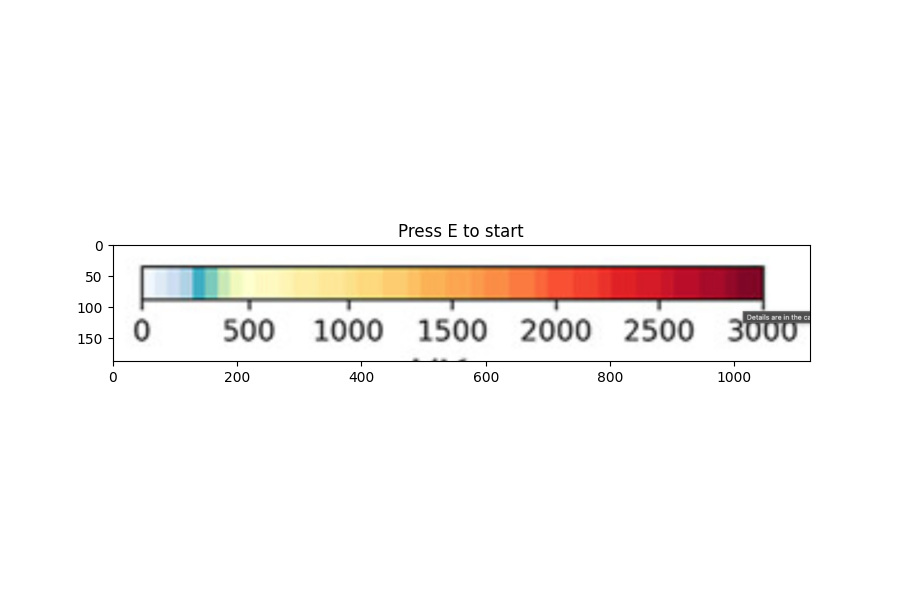

In [ ]:
## Run this cell and follow the instructions in the plot title
## Once you are satisfied with the sampling points, run the next cell to print the color hex codes

extractor = InteractiveColormapExtractor(imread(get_latest_screenshot()))

In [9]:
extractor.print_color_hexcodes()

colors = [
	"#f7fbfe",
	"#deeaf7",
	"#cddcf2",
	"#afd3e8",
	"#3eadc2",
	"#7accbc",
	"#c9e9b4",
	"#effabc",
	"#feffcf",
	"#fef6be",
	"#fefac1",
	"#fef5b4",
	"#feeea4",
	"#fdeea5",
	"#fde899",
	"#fee798",
	"#f9e18a",
	"#fdd97d",
	"#fed97d",
	"#fdcc70",
	"#fbcc70",
	"#fdc063",
	"#fbb256",
	"#fcb256",
	"#fca652",
	"#fca651",
	"#fa9b4b",
	"#fb8d46",
	"#fa8d47",
	"#fb7a40",
	"#fb7b41",
	"#fb683b",
	"#f95034",
	"#f85134",
	"#f3412f",
	"#f1422d",
	"#ea322b",
	"#df2125",
	"#df2225",
	"#d41b27",
	"#d51b27",
	"#ca1628",
	"#b90d2a",
	"#b90e2a",
	"#a80b2a",
	"#a80b2a",
	"#950929",
	"#810728",
]


In [10]:
from matplotlib.colors import LinearSegmentedColormap

colors = [
	"#f7fbfe",
	"#deeaf7",
	"#cddcf2",
	"#afd3e8",
	"#3eadc2",
	"#7accbc",
	"#c9e9b4",
	"#effabc",
	"#feffcf",
	"#fef6be",
	"#fefac1",
	"#fef5b4",
	"#feeea4",
	"#fdeea5",
	"#fde899",
	"#fee798",
	"#f9e18a",
	"#fdd97d",
	"#fed97d",
	"#fdcc70",
	"#fbcc70",
	"#fdc063",
	"#fbb256",
	"#fcb256",
	"#fca652",
	"#fca651",
	"#fa9b4b",
	"#fb8d46",
	"#fa8d47",
	"#fb7a40",
	"#fb7b41",
	"#fb683b",
	"#f95034",
	"#f85134",
	"#f3412f",
	"#f1422d",
	"#ea322b",
	"#df2125",
	"#df2225",
	"#d41b27",
	"#d51b27",
	"#ca1628",
	"#b90d2a",
	"#b90e2a",
	"#a80b2a",
	"#a80b2a",
	"#950929",
	"#810728",
]

cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)